# SQL-расчёты по тестовому заданию

Объединение чеков с магазинами, выборка двух магазинов и расчёт периодов очереди на SQLite. Перепроверка результатов из Excel.

In [1]:
import os
import sqlite3
import pandas as pd

FOLDER    = "."
THRESHOLD = 60
STORES    = (98451680, 12864064)

## Загрузка данных

In [2]:
stores = pd.read_csv(os.path.join(FOLDER, "store_stores.csv"),
                     dtype={"store_id": "int64", "store_uuid": "string"})
queues = pd.read_csv(os.path.join(FOLDER, "store_checkout_queues.csv"), dtype="string")

for c in ("start_operation_dt", "end_operation_dt"):
    queues[c] = pd.to_datetime(queues[c], format="%d.%m.%Y %H:%M:%S").dt.strftime("%Y-%m-%d %H:%M:%S")
for c in ("checks_number", "employees_id", "quantity", "checkout_id1"):
    queues[c] = queues[c].astype("int64")
queues["selling_price"] = queues["selling_price"].astype("float64")

con = sqlite3.connect(":memory:")
stores.to_sql("store_stores", con, index=False)
queues.to_sql("store_checkout_queues", con, index=False)

print("store_stores:", len(stores))
print("store_checkout_queues:", len(queues))

store_stores: 68
store_checkout_queues: 1064703


## Объединение и выборка

Соединение по `store_uuid`, фильтр по магазинам 98451680 и 12864064. `checkout_id1` из файла отдаём как `checkout_id`.

In [3]:
sql_selection = f"""
SELECT
    scq.checks_number       AS checks_number,
    ss.store_id             AS store_id,
    scq.employees_id        AS employees_id,
    scq.quantity            AS quantity,
    scq.selling_price       AS selling_price,
    scq.checkout_id1        AS checkout_id,
    scq.start_operation_dt  AS start_operation_dt,
    scq.end_operation_dt    AS end_operation_dt
FROM store_checkout_queues AS scq
JOIN store_stores          AS ss ON ss.store_uuid = scq.store_uuid
WHERE ss.store_id IN {STORES}
ORDER BY ss.store_id, scq.checkout_id1, scq.start_operation_dt;
"""

selection = pd.read_sql(sql_selection, con)
print("строк:", len(selection))
selection.head(8)

строк: 50581


 checks_number  store_id  employees_id  quantity  selling_price  checkout_id  start_operation_dt    end_operation_dt
      20798825  12864064        164172         4          207.0            6 2024-11-23 14:16:43 2024-11-23 14:17:05
      20798996  12864064        164172         4          383.0            6 2024-11-23 16:22:00 2024-11-23 16:22:18
      20799411  12864064        164172         4          181.0            6 2024-11-23 20:29:57 2024-11-23 20:30:23
      20799504  12864064        164172         3           51.0            6 2024-11-23 21:30:18 2024-11-23 21:30:48
      20799514  12864064        164172         6         1288.0            6 2024-11-23 21:46:03 2024-11-23 21:47:21
      21754255  12864064        164172         4          194.0            6 2024-11-24 11:16:48 2024-11-24 11:17:08
      21754278  12864064        164172         3           47.0            6 2024-11-24 11:32:26 2024-11-24 11:32:55
      21754645  12864064        164172         5          838.0 

## Проверка данных

Касса обслуживает клиентов последовательно, операции не должны накладываться:

- `end >= start` в каждой строке;
- конец предыдущего чека не позже начала следующего на той же кассе (`LAG(end) <= start`).

Обе проверки должны дать 0.

In [4]:
sql_check_neg = f"""
SELECT COUNT(*) FROM store_checkout_queues scq
JOIN store_stores ss ON ss.store_uuid = scq.store_uuid
WHERE ss.store_id IN {STORES} AND scq.end_operation_dt < scq.start_operation_dt;
"""

sql_check_overlap = f"""
WITH sel AS (
    SELECT ss.store_id, scq.checkout_id1 AS checkout_id,
           scq.start_operation_dt AS s, scq.end_operation_dt AS e
    FROM store_checkout_queues scq
    JOIN store_stores ss ON ss.store_uuid = scq.store_uuid
    WHERE ss.store_id IN {STORES}
),
ordered AS (
    SELECT store_id, checkout_id, s, e,
           LAG(e) OVER (PARTITION BY store_id, checkout_id ORDER BY s) AS prev_e
    FROM sel
)
SELECT COUNT(*) FROM ordered WHERE prev_e > s;
"""

neg      = con.execute(sql_check_neg).fetchone()[0]
overlaps = con.execute(sql_check_overlap).fetchone()[0]
print("end < start:", neg)
print("наложений операций:", overlaps)
assert neg == 0 and overlaps == 0

end < start: 0
наложений операций: 0


## Периоды очереди

Пауза до предыдущего чека на кассе; если она больше порога (60 с) — новый непрерывный блок. Блок из двух и более чеков считаем периодом очереди.

In [5]:
sql_periods = f"""
WITH sel AS (
    SELECT ss.store_id, scq.checkout_id1 AS checkout_id,
           scq.start_operation_dt AS s, scq.end_operation_dt AS e
    FROM store_checkout_queues scq
    JOIN store_stores ss ON ss.store_uuid = scq.store_uuid
    WHERE ss.store_id IN {STORES}
),
flagged AS (
    SELECT *, round((julianday(s) - julianday(
        LAG(e) OVER (PARTITION BY store_id, checkout_id ORDER BY s))) * 86400) AS pause_sec
    FROM sel
),
islands AS (
    SELECT *, CASE WHEN pause_sec IS NULL OR pause_sec > {THRESHOLD} THEN 1 ELSE 0 END AS is_new_island
    FROM flagged
),
grouped AS (
    SELECT *, SUM(is_new_island) OVER (PARTITION BY store_id, checkout_id
                                       ORDER BY s ROWS UNBOUNDED PRECEDING) AS island_id
    FROM islands
)
SELECT store_id, checkout_id,
       MIN(s) AS queue_start, MAX(e) AS queue_end,
       COUNT(*) AS checks_in_queue,
       CAST(round((julianday(MAX(e)) - julianday(MIN(s))) * 86400) AS INT) AS duration_sec
FROM grouped
GROUP BY store_id, checkout_id, island_id
HAVING COUNT(*) >= 2
ORDER BY store_id, checkout_id, queue_start;
"""

periods = pd.read_sql(sql_periods, con)
print("периодов:", len(periods))
print("чеков в очереди:", int(periods["checks_in_queue"].sum()))
print("доля:", f'{100*periods["checks_in_queue"].sum()/len(selection):.1f}%')
print("часов:", f'{periods["duration_sec"].sum()/3600:.1f}')
print("макс чеков в периоде:", int(periods["checks_in_queue"].max()))
periods.head(10)

периодов: 7599
чеков в очереди: 40051
доля: 79.2%
часов: 727.3
макс чеков в периоде: 79


 store_id  checkout_id         queue_start           queue_end  checks_in_queue  duration_sec
 12864064            6 2024-11-27 08:05:22 2024-11-27 08:15:59                8           637
 12864064            6 2024-11-27 08:19:12 2024-11-27 08:20:06                2            54
 12864064            6 2024-11-27 08:21:50 2024-11-27 08:47:17               27          1527
 12864064            6 2024-11-27 08:48:22 2024-11-27 08:54:13                5           351
 12864064            6 2024-11-27 08:55:46 2024-11-27 09:00:01                3           255
 12864064            6 2024-11-27 09:03:17 2024-11-27 09:04:01                2            44
 12864064            6 2024-11-27 09:12:37 2024-11-27 09:21:23                4           526
 12864064            6 2024-11-27 09:25:10 2024-11-27 09:27:28                2           138
 12864064            6 2024-11-27 09:28:37 2024-11-27 09:34:17                6           340
 12864064            6 2024-11-27 09:37:18 2024-11-27 09:45:

## Обоснование порога 60 с

Среднее по паузам искажено простоями (ночь, редко используемые кассы), поэтому смотрю на медиану и распределение. На загруженных кассах типичная пауза между чеками 15-25 секунд, и 64% всех пауз укладываются в 60 секунд. Сам порог примерно равен среднему времени обслуживания чека (около 53 секунд): если касса простаивает дольше, очереди нет.

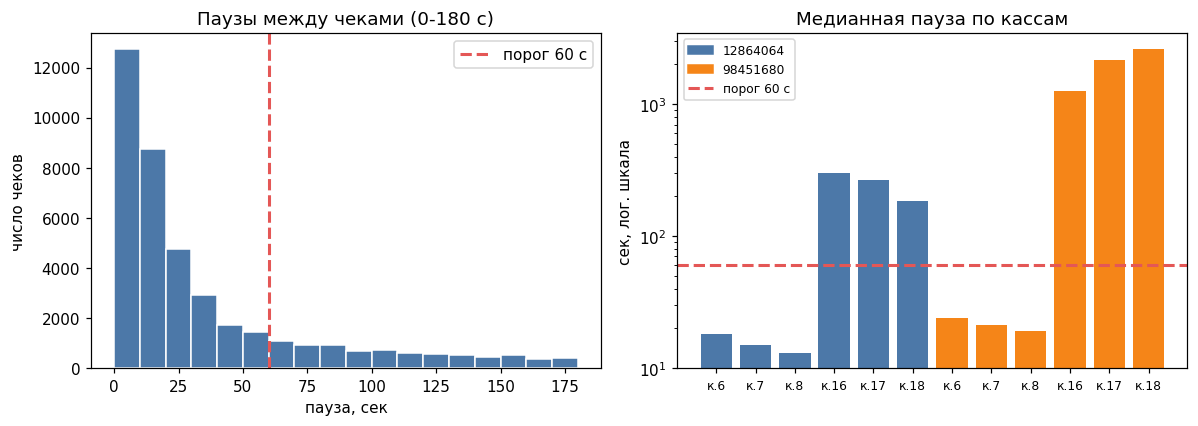

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sel = selection.copy()
sel["start"] = pd.to_datetime(sel["start_operation_dt"])
sel["end"]   = pd.to_datetime(sel["end_operation_dt"])
sel = sel.sort_values(["store_id", "checkout_id", "start"])
sel["pause"] = (sel["start"] - sel.groupby(["store_id", "checkout_id"])["end"].shift()).dt.total_seconds()
pauses = sel["pause"].dropna()
med = sel.groupby(["store_id", "checkout_id"])["pause"].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(pauses[pauses <= 180], bins=18, color="#4C78A8", edgecolor="white")
ax1.axvline(60, color="#E45756", linestyle="--", linewidth=2, label="порог 60 с")
ax1.set_title("Паузы между чеками (0-180 с)")
ax1.set_xlabel("пауза, сек")
ax1.set_ylabel("число чеков")
ax1.legend()

ax2.bar(range(len(med)), med.values,
        color=["#4C78A8" if s == 12864064 else "#F58518" for s, c in med.index])
thr = ax2.axhline(60, color="#E45756", linestyle="--", linewidth=2, label="порог 60 с")
ax2.set_yscale("log")
ax2.set_xticks(range(len(med)))
ax2.set_xticklabels([f"к.{c}" for s, c in med.index], fontsize=8)
ax2.set_title("Медианная пауза по кассам")
ax2.set_ylabel("сек, лог. шкала")
ax2.legend(handles=[mpatches.Patch(color="#4C78A8", label="12864064"),
                    mpatches.Patch(color="#F58518", label="98451680"), thr], fontsize=8)

plt.tight_layout()
plt.show()